# Numerical solution of differential equations - boundary value problem

## Solving two-point boundary value problems

By a two-point boundary value problem we mean a second-order ordinary differential equation of the form:

$$\ddot y=f(t, y, \dot y),$$

subject to prescribed *boundary conditions*:

$$y(a)=\alpha\qquad\textrm{in}\qquad y(b)=\beta.$$

The methods we learned for solving *initial value problems* are not directly applicable here, because we do not have the derivative specified at the initial point $t=a$.

In what follows we will look at two different approaches to solving boundary value problems:

1. the so-called **shooting method**,
2. the **finite difference method**.

## Shooting method

We solve the boundary value problem:

$$\ddot y=f(t, y, \dot y),\qquad y(a)=\alpha,\quad y(b)=\beta,$$

which we convert into an initial value problem by choosing:

$$\dot y (a)=u.$$

We solve the problem with numerical methods for the initial value problem and denote the solution by $\theta(u, t)$.

The boundary value problem is solved once we choose $u$ such that:

$$r(u)=\theta(u,b)-\beta=0.$$

We have obtained a nonlinear equation that we must solve; to compute the value of the boundary residual $r(u)$ we must numerically solve the initial value problem.

To solve the equation $r(u)=0$ we can use the secant method. We choose $u_0$ and $u_1$ and at the $i$-th step we compute:

$$u_{i+1}=u_i-r(u_i)\,\frac{u_{i}-u_{i-1}}{r(u_{i})-r(u_{i-1})},\qquad i=2,3,\dots$$

We stop when:

$$\left|r(u_{i+1})\right|<\epsilon.$$

The solution of the shooting method carries the error $\epsilon$ of the method for solving the nonlinear equation and the error of the numerical method for solving the initial value problem.

### Numerical example: projectile motion

The figure shows a projectile of mass $m$ launched with velocity $\textbf{v}_0$.
![Projectile motion](./fig/posevni_met.png)

The magnitude of the air-drag force is $|\textbf{F}|=c\,|\textbf{v}|^2$, then the equations of motion are:

$$x''(t)=F_x/m\qquad y''(t)=F_y/m-g.$$

The force components are (see the derivation in the chapter on solving the initial value problem of a system of differential equations):

$$F_x=-c\,x'\,\sqrt{x'^2+y'^2},\qquad F_y=-c\,y'\,\sqrt{x'^2+y'^2}.$$

#### Vertical launch

First we assume that $\varphi=90$° and therefore there is no motion in the $x$ direction. We are interested in the solution where the projectile is launched from height $y=0$ m and must, at time $t=b=1$ s, be at height $y(b)=10$ m. We have defined the boundary value problem:

$$y''(t)=F_y\,/m-g,\qquad y(0)=0,\quad y(1)=10.$$

First we must transform the second-order equation:

$$y''=f(t, y, y') = F_y/m-g$$

into a system of two first-order equations. We use $y_i=y^{(i)}$ and take into account $F_y=-c\,y'\,\sqrt{y'^2}$.

We differentiate $y_i'=y_{i+1}$ and set up the system of first-order equations:

$$
\begin{array}{rcl}
y'_0&=&y_1\\
y'_1&=&-c\,y'\,\sqrt{y'^2}/m-g
\end{array}
$$

Let us import the modules `numpy` and `scipy.integrate.solve_ivp`:

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

Let us prepare the list of right-hand-side functions:

In [2]:
def f_vert(t, y, g=9.81, m=1., c=0.5):
    return np.array([y[1], -g-c*y[1]*np.sqrt(y[1]**2)/m])

and we prepare a function to compute the boundary residual at time $b$ as a function of the initial velocity $v_0$ (the default air drag is $c=0.1$):

In [3]:
def r(v0=100., t=None, target_position=10., g=9.81, m=1., c=0.1):
    def f_vert_tmp(t, y): # prepare a function with the desired parameters
        return f_vert(t, y, g=g, m=m, c=c)
    sol = solve_ivp(f_vert_tmp, t_span=(t[0], t[-1]), y0=np.array([0., v0]))
    r = sol.y[0,-1] - target_position
    return r

Let us check the boundary residual for the initial condition $v_0=y'=50$ m/s:

In [4]:
t = np.linspace(0, 1, 100)
r(v0=50., t=t)

np.float64(5.63455093999735)

We observe that at 1 second the mass is 5.635 m above the target height.

Our goal is for the mass to reach the position of 10 m at 1 second with accuracy `1e-6`:

In [5]:
target_position = 10
epsilon = 1e-6

Let us now carry out the secant method:

In [6]:
x0 = 100
x1 = 50
for i in range(10):
    f0 = r(v0=x0, t=t, target_position=target_position)
    f1 = r(v0=x1, t=t, target_position=target_position)
    x2 = x1 - f1 * (x1 - x0)/(f1 - f0)
    err = r(v0=x2, t=t, target_position=target_position)
    print(f'The new estimate is v0={x2}, the error is {err}.')
    x0 = x1
    x1 = x2
    if abs(err)<epsilon:
        solution = x2
        print(f'Solution v0={solution}')
        break

The new estimate is v0=5.644178759347113, the error is -9.672536331804414.
The new estimate is v0=33.67258709458857, the error is 2.2187017725280302.
The new estimate is v0=28.442965190719487, the error is 0.8225839451367332.
The new estimate is v0=25.361704474139284, the error is -0.10153714557803362.
The new estimate is v0=25.70025579721459, the error is 0.004276366407131249.
The new estimate is v0=25.686573522825174, the error is 2.16308919487318e-05.
The new estimate is v0=25.686503962731987, the error is -4.623860405672531e-09.
Solution v0=25.686503962731987


Let us now look at the computed solution:

In [7]:
sol = solve_ivp(lambda t, y: f_vert(t, y, c=0.1),
                t_span=(t[0], t[-1]), y0=np.array([0., solution]),
                t_eval=t
               )

Above we used a `lambda` expression ([documentation](https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions)). The expression `lambda t, y: f_vert(t, y, c=0.1)` is equivalent to:

```python
def function_name(t, y):
    return f_vert(t, y, c=0.1)
```

Let us import `matplotlib`:

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

We display the result:

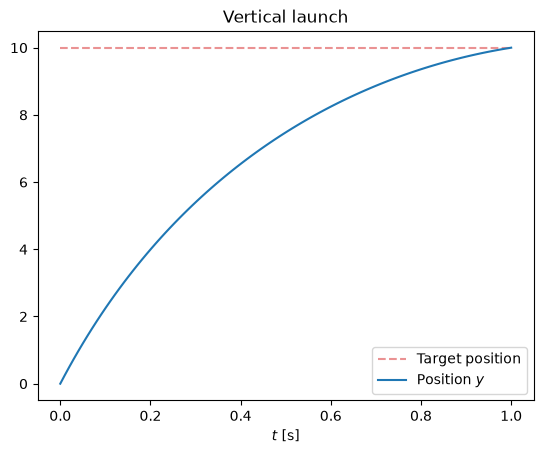

In [9]:
plt.title('Vertical launch')
plt.hlines(target_position,0., 1, 'C3', linestyles='dashed', label='Target position', alpha=0.5)
plt.plot(sol.t, sol.y[0], label='Position $y$')
plt.xlabel('$t$ [s]')
plt.legend(loc=4)
plt.show()

#### Projectile (oblique) launch

Let us now look at a general projectile (oblique) launch (the differential equations are already defined above). First we must transform the system of second-order differential equations into a system of first-order equations.

We use:

$$y_0=x,~ y_1=x',~ y_2=y,~ y_3=y'$$

and we obtain the system of first-order differential equations:

$$
\begin{array}{rcl}
y_0'&=&y_1\\
y_1'&=&F_x/m\\
y_2'&=&y_3\\
y_3'&=&F_y/m-g.\\
\end{array}
$$

Let us prepare the list of right-hand-side functions:

In [10]:
def f_oblique(t, y, g=9.81, m=1., c=0.1):
    x, vx, yy, vy = y
    return np.array([vx, -c*vx*np.sqrt(vx**2+vy**2)/m, vy, -g-c*vy*np.sqrt(vx**2+vy**2)/m])

Let us also prepare a function to compute the boundary residual at time $b=1$ as a function of the initial velocity vector $\mathbf{v}_0$:

In [11]:
def r_oblique(v0=[5., 100.], t=None, target_position=np.array([10, 5.]), g=9.81, m=1., c=0.1):
    sol = solve_ivp(lambda t, y: f_oblique(t, y, g=g, m=m, c=c),
                      t_span=(t[0], t[-1]),
                      y0=[0, v0[0], 0, v0[1]])
    r = sol.y[0:3:2, -1] - target_position
    return r

Let us check the boundary residual for the initial condition $\mathbf{v}_0=[100., 100.]$ m/s:

In [12]:
r_oblique(v0=[100., 100.],t=t)

array([ 9.66195325, 11.84726075])

For finding the root of a system of nonlinear functions we have already encountered the function ``scipy.optimize.root`` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html)):

```python
root(fun, x0, args=(), method='hybr', jac=None,
     tol=None, callback=None, options=None)
```
First we import it:

In [13]:
from scipy import optimize

Then we use it with an initial guess $\mathbf{v}_0$:

In [14]:
solution = optimize.root(r_oblique, np.array([100., 100.]), args=(t,))

The solution is:

In [15]:
solution

 message: The solution converged.
 success: True
  status: 1
     fun: [ 1.155e-13 -3.260e-13]
       x: [ 1.938e+01  1.655e+01]
  method: hybr
    nfev: 19
    fjac: [[-9.339e-01  3.575e-01]
           [-3.575e-01 -9.339e-01]]
       r: [-4.078e-01  2.409e-01 -3.754e-01]
     qtf: [ 1.067e-09 -1.311e-09]

The attribute `solution.x` contains the vector of computed solutions (`[19.37894314,  16.55482478]`). Let us check the boundary residual at the computed solution:

In [16]:
r_oblique(v0=solution.x, t=t)

array([ 1.15463195e-13, -3.25961480e-13])

Let us now look at the computed solution:

In [17]:
sol = solve_ivp(lambda t, y: f_oblique(t, y, g=9.81, m=1., c=.1),
                t_span=(t[0], t[-1]),
                y0=[0, solution.x[0], 0, solution.x[1]],
                t_eval=t)

We display the result:

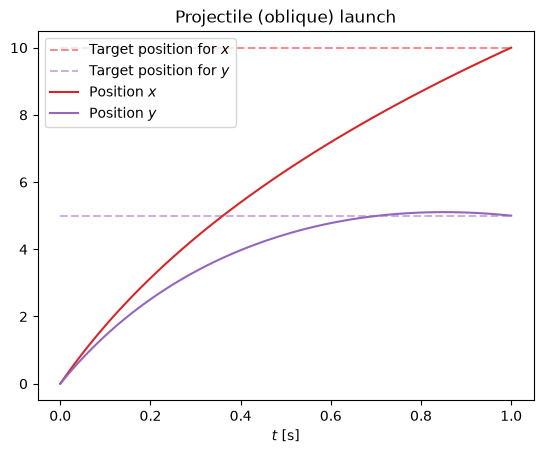

In [18]:
plt.title('Projectile (oblique) launch')
plt.hlines(10,0., 1, 'C3', linestyles='dashed', label='Target position for $x$', alpha=0.5)
plt.hlines(5,0., 1, 'C4', linestyles='dashed', label='Target position for $y$', alpha=0.5)
plt.plot(sol.t, sol.y[0], label='Position $x$', color='C3')
plt.plot(sol.t, sol.y[2], label='Position $y$', color='C4')
plt.xlabel('$t$ [s]')
plt.legend()
plt.show()

### Using `scipy.integrate.solve_bvp`

Instead of `scipy.integrate.solve_ivp` and `scipy.optimize` we can use the built-in function for solving boundary value problems `scipy.integrate.solve_bvp` (BVP - Boundary Value Problem):
```python
scipy.integrate.solve_bvp(fun, bc, x, y,
                          p=None, S=None, fun_jac=None, bc_jac=None,
                          tol=0.001, max_nodes=1000, verbose=0)
```

An explanation of all the arguments is in the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html#scipy-integrate-solve-bvp); here we will highlight a few:

* `fun` is the right-hand side (`func(t, y...)`),
* `bc` is the boundary residual: `bc(y(a), y(b)) = 0`
* `x` numeric array (dimension `(m)`) of the independent variable `x[0]=a` and `x[-1]=b`,
* `y` numeric array (dimension `(n, m)`) of initial values.

The result of calling `solve_bvp` is an object with attributes (selected):

* `x` the values of the independent variable at which the result is computed,
* `y` the result,
* `sol` the result in the form of a cubic spline,
* `success` is `True` if the solution has converged.

Let us look at an example:

In [19]:
from scipy.integrate import solve_bvp

Let us define the independent variable

In [20]:
t = np.linspace(0, 1, 15)

And the boundary residual (we want the position at time `b` to be $x=10$ m and $y=5$ m):

In [21]:
def boundary_residual(ya, yb):
    return np.array([ya[0], ya[2], yb[0]-10, yb[2]-5])

Let us also define the initial velocity values (as an initial guess):

In [22]:
y0 = np.zeros((4, t.size))
y0[1] = 5   # velocity in the x direction
y0[3] = 100 # velocity in the y direction

In [23]:
y0[:,:3]

array([[  0.,   0.,   0.],
       [  5.,   5.,   5.],
       [  0.,   0.,   0.],
       [100., 100., 100.]])

And let us solve the boundary value problem and the description of the result

In [24]:
sol = solve_bvp(lambda t, y: f_oblique(t, y, g=9.81, m=1., c=.1),
                bc=boundary_residual, x=t, y=y0)

In [25]:
sol

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  2.381e-02 ...  9.762e-01  1.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7e1922de8f20>
             p: None
             y: [[-1.588e-22  4.482e-01 ...  9.853e+00  1.000e+01]
                 [ 1.939e+01  1.828e+01 ...  6.210e+00  6.117e+00]
                 [-3.176e-22  3.801e-01 ...  5.031e+00  5.000e+00]
                 [ 1.656e+01  1.539e+01 ... -1.189e+00 -1.403e+00]]
            yp: [[ 1.939e+01  1.828e+01 ...  6.210e+00  6.117e+00]
                 [-4.944e+01 -4.369e+01 ... -3.926e+00 -3.839e+00]
                 [ 1.656e+01  1.539e+01 ... -1.189e+00 -1.403e+00]
                 [-5.205e+01 -4.659e+01 ... -9.058e+00 -8.929e+00]]
 rms_residuals: [ 4.302e-05  3.582e-05 ...  1.297e-06  4.151e-06]
         niter: 2

Let us display the result:

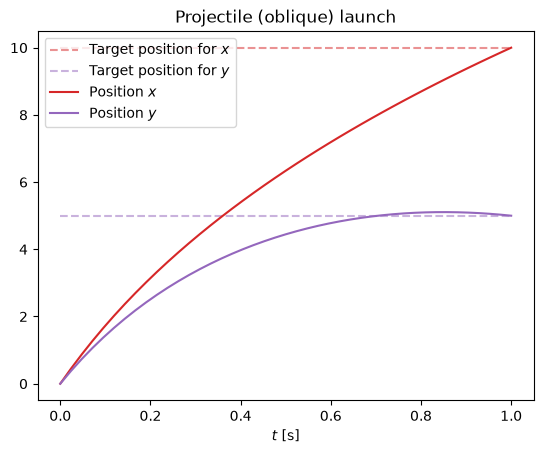

In [26]:
plt.title('Projectile (oblique) launch')
plt.hlines(10,0., 1, 'C3', linestyles='dashed', label='Target position for $x$', alpha=0.5)
plt.hlines(5,0., 1, 'C4', linestyles='dashed', label='Target position for $y$', alpha=0.5)
plt.plot(sol.x, sol.y[0], label='Position $x$', color='C3')
plt.plot(sol.x, sol.y[2], label='Position $y$', color='C4')
plt.xlabel('$t$ [s]')
plt.legend()
plt.show()

### Numerical example: loaded beam

Let us look at a beam:
![Beam](./fig/nosilec.png)

The deflection $w(x)$ of the beam is described by a fourth-order differential equation:

$$-E\,I\frac{\textrm{d}^4}{\textrm{d}x^4}w(x)+q(x)=0.$$

The known constants are $E,I,l$ and $q(x)$ is the distributed load.

Boundary conditions (simply supported beam):

$$w(0)=w(l)=0\quad\textrm{in}\quad w''(0)=w''(l)=0$$

The parameters are:

* $I=2.1\cdot10^{-5}$ m $^4$,
* $E=2.1\cdot10^{11}$ N/m $^2$,
* $l=10$ m.

The distributed load $q(x)$ will be defined later.

First we must transform the fourth-order differential equation into a system of first-order differential equations.
We use:

$$y_0=w,~ y_1=w',~ y_2=w'',~ y_3=w'''$$

and we obtain the system of first-order differential equations:

$$
\begin{array}{rcl}
y_0'&=&y_1\\
y_1'&=&y_2\\
y_2'&=&y_3\\
y_3'&=&q(x)/(EI).\\
\end{array}
$$

Let us prepare various distributed loads:

In [27]:
def q_constant(x, F_0=1e3, l=10):
    return -F_0*np.ones_like(x)

def q_triangular(x, F_0=1e3, l=10):
    return -F_0*x/l

def q_half_sine(x, F_0=1e3, l=10):
    return -F_0*np.sin(np.pi*x/l)

Let us define the length (for the other parameters, $I, E$, we will use the defaults):

In [28]:
l = 10.

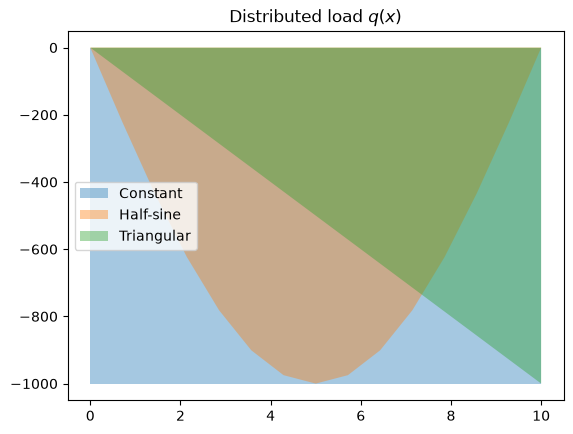

In [29]:
x = np.linspace(0, l, 15)
plt.fill_between(x, q_constant(x), alpha=0.4, label='Constant')
plt.fill_between(x, q_half_sine(x), alpha=0.4, label='Half-sine')
plt.fill_between(x, q_triangular(x), alpha=0.4, label='Triangular')
plt.title('Distributed load $q(x)$')
plt.legend()
plt.show()

Let us prepare the list of right-hand-side functions:

In [30]:
def f_beam_constant(x, y, E=2.1e11, I=2.1e-5):
    return np.array([y[1], y[2], y[3], q_constant(x)/(E*I)], dtype=float)
def f_beam_half_sine(x, y, E=2.1e11, I=2.1e-5):
    return np.array([y[1], y[2], y[3], q_half_sine(x)/(E*I)])
def f_beam_triangular(x, y, E=2.1e11, I=2.1e-5):
    return np.array([y[1], y[2], y[3], q_triangular(x)/(E*I)])

Let us now define the boundary conditions, i.e. the boundary residual (the deflection and the moment at the ends are both zero):

In [31]:
def boundary_beam(ya, yb):
    return np.array([ya[0], ya[2], yb[0], yb[2]])

Let us also define the initial values of the slope ($w'$) and the shear force ($w'''$) (as an initial guess):

In [32]:
y0 = np.zeros((4, x.size), dtype=float)
# those that are not known could also be left as zero:
# y0[1] = 1. # w'
# y0[3] = 1. # w'''

And let us solve the boundary value problem (for all three load types):

In [33]:
sol_const = solve_bvp(f_beam_constant, bc=boundary_beam, x=x, y=y0)
sol_half_sin = solve_bvp(f_beam_half_sine, bc=boundary_beam, x=x, y=y0)
sol_triangular = solve_bvp(f_beam_triangular, bc=boundary_beam, x=x, y=y0)

Let us display the result for the constant load:

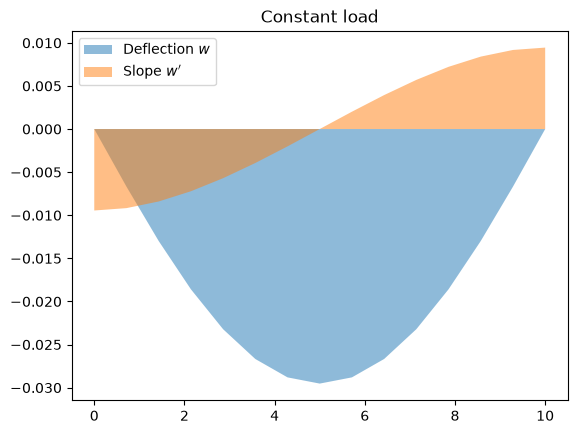

In [34]:
plt.fill_between(sol_const.x, sol_const.y[0], label='Deflection $w$', alpha=0.5)
plt.fill_between(sol_const.x, sol_const.y[1], label='Slope $w\'$', alpha=0.5)
plt.title('Constant load')
plt.legend()
plt.show()

And a comparison of the deflection for the different load types:

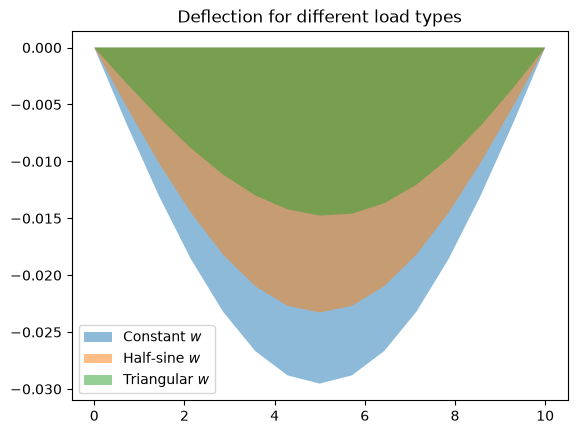

In [35]:
plt.fill_between(sol_const.x, sol_const.y[0], label='Constant $w$', alpha=0.5)
plt.fill_between(sol_half_sin.x, sol_half_sin.y[0], label='Half-sine $w$', alpha=0.5)
plt.fill_between(sol_triangular.x, sol_triangular.y[0], label='Triangular $w$', alpha=0.5)
plt.title('Deflection for different load types')
plt.legend()
plt.show()

## Finite difference method

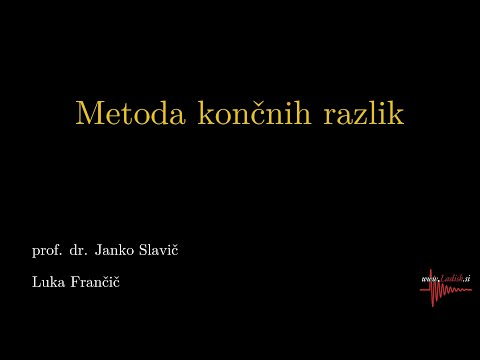

In [36]:
from IPython.display import YouTubeVideo
YouTubeVideo('YozKGsNYZ6Y', width=800, height=300)

We solve the boundary value problem:

$$y''=f(t, y, y'),\qquad y(a)=\alpha,\quad y(b)=\beta.$$

So we have:

$$a=t_0,\quad b=t_{n-1}.$$

In the finite difference method for solving the boundary value problem we use a difference scheme. Assume we have an interval $[a,b]$ over which we solve the differential equation (the independent variable) divided into equal subintervals (there are $n$ points):

$$t=[t_0, t_1,\dots, t_{n-1}].$$

We replace the derivatives with the central difference scheme:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-2}$|$y_{i-1}$ | $y_{i}$   |$y_{i+1}$ |$y_{i+2}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{h}\cdot$| 0     | -0.5 | 0 | 0.5 | 0|
|$y_i''=\frac{1}{h^2}\cdot$| 0 | 1 | -2 | 1 | 0|
|$y_i'''=\frac{1}{h^3}\cdot$| -0.5 | 1 | 0 | -1 | 0.5|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 1 | -4 | 6 | -4 | 1|

The central difference scheme shown has a second-order error $\mathcal{O}(h^{2})$.

At the $i$-th point we write the second-order ordinary differential equation with central differences as:

$$\frac{1}{h^2}\left(y_{i-1}-2\,y_{i}+y_{i+1}\right)+\mathcal{O}(h^{2})=f\left(t_i, y_i,
\frac{1}{2h}\left(-y_{i-1}+y_{i+1}\right)+\mathcal{O}(h^{2})\right).$$

If we neglect the error of the method:

$$\frac{1}{h^2}\left(y_{i-1}-2\,y_{i}+y_{i+1}\right)=f\left(t_i, y_i,
\frac{1}{2h}\left(-y_{i-1}+y_{i+1}\right)\right),\qquad i=1,2,\dots,n-2.$$

The above equation can be written for the $n-2$ interior points, which means that to obtain a solvable system of equations for $n$ unknowns we are still missing two equations. These two equations are the boundary conditions:

$$y_0=\alpha,\quad y_{n-1}=\beta.$$

In the case of a linear boundary value problem, to compute the $n$ unknowns $y_i$ we must solve a system of $n$ linear equations (and if it is nonlinear, then a system of nonlinear equations).

#### Error estimate

The exact result $y(t_{i})$ at step size $h$ is:

$$y(t_{i})=y_{i,h}+E_{i,h},$$

where $y_{i,h}$ is the numerical approximation and $E_h$ the error of the method. Since the global error is of second order, we can write the error as:

$$E_{i,h}=k\,h^2,$$

Similarly, for step size $2h$ we can write:

$$y(t_{j})=y_{j,2h}+E_{j,2h},$$

where $y_{j,2h}$ is the numerical approximation and $E_{2h}$ the error of the method and:

$$E_{j,2h}=k\,(2\,h)^2=4\,k\,h^2$$

Assuming that the constant $k$ is the same at step $h$ and step $2h$, we can determine the error estimate at the better approximation $E_h$. First we equate the exact result $y(t_{i})$ at step $h$ and the result $y(t_{j})$ at step $2h$ (with $i=2\,j$, $j=1,2,\dots$):

$$y_{i,h}+k\,h^2=y_{j,2h}+4\,k\,h^2$$

it follows that:

$$3\,k\,h^2=y_{2j,h}-y_{j,2h}$$

and then we compute the *error estimate*:

$$E_{j,h}=\frac{y_{2j,h}-y_{j,2h}}{3}.$$

### Numerical example: vertical launch

Above we solved the vertical launch with the shooting method; let us now use the finite difference method. First the boundary value problem:

$$y''(t)=F_y/m-g,\qquad y(0)=0,\quad y(1)=10.$$

is written using the central difference scheme ($F_y=-c\,y'$):

$$\frac{1}{h^2}\left(y_{i-1}-2\,y_{i}+y_{i+1}\right)= -c\left(\frac{1}{2h}\left(-y_{i-1}+y_{i+1}\right)\right)/m-g.$$

(Here we have assumed that the air drag depends linearly on the velocity. Otherwise we would have a nonlinear boundary value problem, and consequently we would develop a system of nonlinear equations.)

We rearrange the above expression:

$$(2-c\,h/m)\,y_{i-1}-4\,y_{i}+(2+c\,h/m)\,y_{i+1}=-2\,g\,h^2,\qquad i=1,2,\dots,n-2.$$

The boundary conditions are:

$$y_0=0,\qquad y_{n-1}=10$$

We have thus transformed the boundary value problem into a system of $n$ linear equations. Let us now look at a concrete computation for $n=11$; first let us define the constants, the time vector `t` and the step `h`:

In [37]:
n = 11 # odd number
c = 0.5
m = 1.0
g = 9.81
t = np.linspace(0, 1, n)
h = t[1]

Then we continue with the computation of the tridiagonal coefficient matrix `A`.

We use the function `numpy.diag()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.diag.html)):

```python
numpy.diag(v, k=0)
```
with the parameters:

* `v` the vector to be placed on the diagonal,
* `k` the diagonal to which `v` is assigned. `k=0` is used for the main diagonal, `k<0` and `k>0` are used for the diagonals below and above the main diagonal.

In [38]:
A = np.diag(-4*np.ones(n), 0) + \
    (2-c*h/m)*np.diag(np.ones(n-1), -1) + \
    (2+c*h/m)*np.diag(np.ones(n-1), 1)
A[:4,:4]

array([[-4.  ,  2.05,  0.  ,  0.  ],
       [ 1.95, -4.  ,  2.05,  0.  ],
       [ 0.  ,  1.95, -4.  ,  2.05],
       [ 0.  ,  0.  ,  1.95, -4.  ]])

Let us also define the vector of constants:

In [39]:
b = -2*g*h**2 * np.ones(n)

Now we *adjust* the coefficient matrix `A` and the vector of constants `b` to satisfy the boundary conditions:

$$y_0=0,\quad y_{n-1}=10.$$

In [40]:
A[0,0] = 1
A[0,1] = 0
A[-1,-2] = 0
A[-1,-1] = 1

In [41]:
b[0] = 0.
b[-1] = 10.

Let us solve the system of linear equations:

In [42]:
y_fdm = np.linalg.solve(A, b)

We display the result:

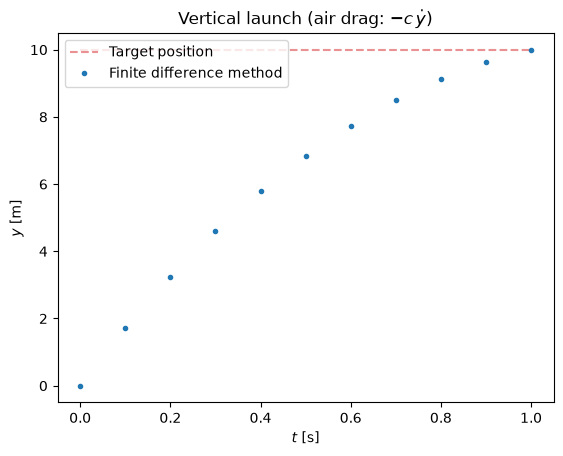

In [43]:
plt.title(r'Vertical launch (air drag: $-c\,\dot y$)')
plt.hlines(10, 0, 1, 'C3', label='Target position', linestyles='dashed', alpha=0.5)
plt.plot(t, y_fdm, '.', label='Finite difference method')
plt.xlabel('$t$ [s]')
plt.ylabel('$y$ [m]')
plt.legend()
plt.show()

Using the function [`numpy.gradient()`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) we also compute the velocity and acceleration:

In [44]:
v_fdm = np.gradient(y_fdm,h, edge_order=2)
a_fdm = np.gradient(v_fdm,h, edge_order=2)
v_fdm[:4]

array([17.99109496, 16.20009044, 14.45276895, 12.79068266])

Let us now also compute the result with a double step:

In [45]:
n2h = n//2+1
t2h = np.linspace(0, 1, n2h)
h2h = t2h[1]
A2h = np.diag(-4*np.ones(n2h), 0) + \
    (2-c*h2h/(m))*np.diag(np.ones(n2h-1), -1) + \
    (2+c*h2h/(m))*np.diag(np.ones(n2h-1), 1)
b2h = -2*g*h2h**2 * np.ones(n2h)
A2h[0,0] = 1
A2h[0,1] = 0
A2h[-1,-1] = 1
A2h[-1,-2] = 0
b2h[0] = 0.
b2h[-1] = 10.
y2h_fdm = np.linalg.solve(A2h, b2h)

Let us compare the first six results at step $2h$:

In [46]:
y2h_fdm[:6]

array([ 0.        ,  3.24082594,  5.7992875 ,  7.74037178,  9.12287659,
       10.        ])

with every second result at step $h$:

In [47]:
y_fdm[:12:2]

array([ 0.        ,  3.24001809,  5.79815462,  7.73931207,  9.12221538,
       10.        ])

Now we can estimate the error:

In [48]:
(y_fdm[::2]-y2h_fdm)/3

array([ 0.        , -0.00026928, -0.00037763, -0.00035324, -0.0002204 ,
        0.        ])

### Numerical example: loaded beam

Let us return to the boundary value problem of the beam with a half-sine load ($q(x)=-F_0\,\sin(\pi\,x/l))$), which we already treated with the shooting method.

We write the fourth-order differential equation using the central difference scheme (for the $i$-th point):

$$-\frac{E\,I}{h^4}\left(1\,w_{i-2} - 4\,w_{i-1} + 6\,w_{i} - 4\,w_{i+1} + 1\, w_{i+2}\right) - F_0\,\sin(\pi\,x_i/l)= 0.$$

There are four boundary conditions, first the deflection at the ends:

$$w_0=w_{n-1}=0$$

Since there is no moment at the ends, the second derivative is zero. Using the central difference scheme we therefore write the additional equations:

$$w_{-1}-2\,w_{0}+w_{1}=0\qquad w_{n-2}-2\,w_{n-1}+w_{n}=0.$$

If for the independent variable $x$ we use $n$ equidistant points, then we write the fourth-order differential equation for the $n-2$ interior points. In doing so we obtain the two additional non-physical points $w_{-1}$ and $w_n$. If we add the four boundary conditions as well, we have a solvable system of linear equations with $n+2$ unknowns and $n+2$ equations.

First let us prepare the data, the independent variable `x` and the step `h`:

In [49]:
l = 10.
E = 2.1e11
I = 2.1e-5
F_0= 1e3
n = 100
x = np.linspace(0, l, n)
h = x[1]

Then we prepare the coefficient matrix (the matrix has dimension `(n, n)`; in the first and last two rows we could also write the values 0, which we will fix later):

In [50]:
A = +1*np.diag(np.ones(n-2+2), -2) \
    -4*np.diag(np.ones(n-1+2), -1) \
    +6*np.diag(np.ones(n+2), 0)  \
    -4*np.diag(np.ones(n-1+2), +1)  \
    +1*np.diag(np.ones(n-2+2), +2)
A[:4,:4]

array([[ 6., -4.,  1.,  0.],
       [-4.,  6., -4.,  1.],
       [ 1., -4.,  6., -4.],
       [ 0.,  1., -4.,  6.]])

Let us also define the vector of constants (we add one element at the end and one at the beginning):

In [51]:
b = np.zeros(n+2)
b[2:-2] = - h**4 * F_0*np.sin(np.pi*x[1:-1]/l)/(E*I)
b[:4]

array([ 0.00000000e+00,  0.00000000e+00, -7.48966545e-10, -1.49717894e-09])

Now we *adjust* the coefficient matrix `A` and the vector of constants `b` to satisfy
the boundary conditions.

First $w_0=w_{n-1}=0$:

In [52]:
A[0,:3]= np.array([0, 1, 0])
b[0] = 0
A[-1,-3:]= np.array([0, 1, 0])
b[-1] = 0

Then $w_{-1}-2\,w_{0}+w_{1}=0$ and $w_{n-2}-2\,w_{n-1}+w_{n}=0$:

In [53]:
A[1,:4] = np.array([1, -2, 1,0])
b[1] = 0
A[-2,-4:] = np.array([0, 1, -2, 1])
b[-2] = 0

In [54]:
A[:5,:5]

array([[ 0.,  1.,  0.,  0.,  0.],
       [ 1., -2.,  1.,  0.,  0.],
       [ 1., -4.,  6., -4.,  1.],
       [ 0.,  1., -4.,  6., -4.],
       [ 0.,  0.,  1., -4.,  6.]])

In [55]:
A[-5:,-5:]

array([[ 6., -4.,  1.,  0.,  0.],
       [-4.,  6., -4.,  1.,  0.],
       [ 1., -4.,  6., -4.,  1.],
       [ 0.,  0.,  1., -2.,  1.],
       [ 0.,  0.,  0.,  1.,  0.]])

In [56]:
b[:5]

array([ 0.00000000e+00,  0.00000000e+00, -7.48966545e-10, -1.49717894e-09,
       -2.24388381e-09])

In [57]:
b[-5:]

array([-2.24388381e-09, -1.49717894e-09, -7.48966545e-10,  0.00000000e+00,
        0.00000000e+00])

Let us solve the system of linear equations:

In [58]:
y_fdm = np.linalg.solve(A, b)

We display the result:

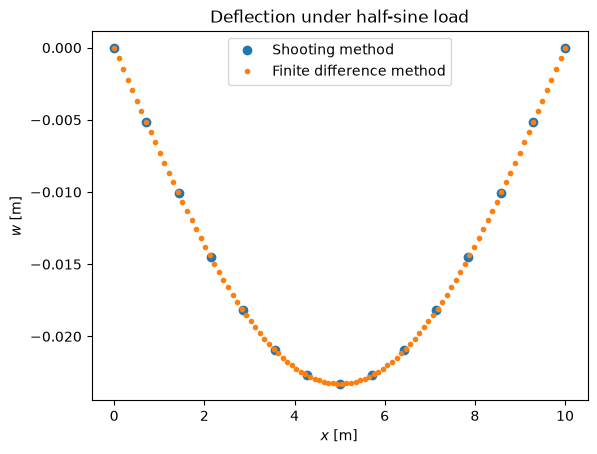

In [59]:
plt.title('Deflection under half-sine load')
plt.plot(sol_half_sin.x, sol_half_sin.y[0], 'o', label='Shooting method')
plt.plot(x, y_fdm[1:-1], '.', label='Finite difference method')
plt.xlabel('$x$ [m]')
plt.ylabel('$w$ [m]')
plt.legend()
plt.show()

## Additional: symbolic solution of the beam

Here we will look at solving the boundary value problem symbolically. It should be emphasized that this is merely an example that we can carry out for the beam under consideration with the relatively simple half-sine load. **In practice, of course, the loads and also the beam shapes can be substantially more complex, and then there is almost no option other than numerical solving.**

First we import `sympy`:

In [60]:
import sympy as sym
sym.init_printing()

Let us define the variables:

In [61]:
w = sym.Function('w')
x, E, I, F_0, l = sym.symbols('x, E, I, F_0, l')

Let us define the differential equation (we add the boundary conditions later):

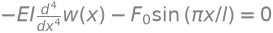

In [62]:
eq = sym.Eq(-E*I*w(x).diff(x,4)-F_0*sym.sin(sym.pi*x/l),0)
eq

Let us solve it:

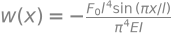

In [63]:
sol = sym.dsolve(eq, func=w(x), hint='nth_linear_constant_coeff_undetermined_coefficients',
                 ics={
                     w(0):0,                      #deflection at x=0 is zero
                     w(x).diff(x,2).subs(x, 0): 0,#moment at x=0 is zero
                     w(x).subs(x, l): 0,                     #deflection at x=l is zero
                     w(x).diff(x, 2).subs(x, l): 0 #moment at x=l is zero
                 })
sol

In [64]:
data = {E: 2.1e11, I: 2.1e-5, l: 10, F_0:1e3}
solution_np = sym.lambdify(x, sol.rhs.subs(data), modules='numpy')
x_ana = np.linspace(0, data[l], 100)
y_ana = solution_np(x_ana)

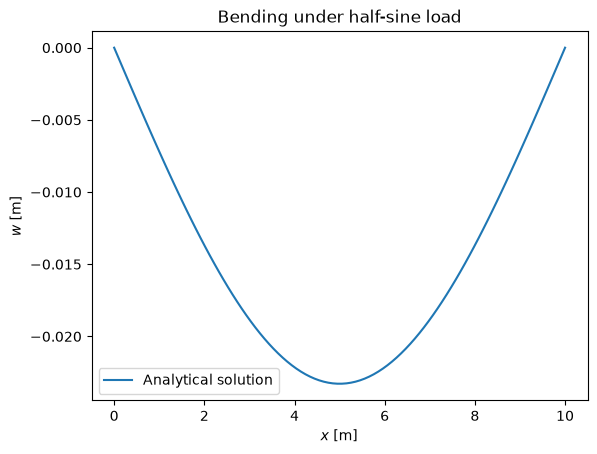

In [65]:
plt.title('Bending under half-sine load')
plt.plot(x_ana, y_ana, '-', label='Analytical solution')
plt.xlabel('$x$ [m]')
plt.ylabel('$w$ [m]')
plt.legend()
plt.show()

Let us now compare the analytical solution with the solution from the finite difference method and the shooting method:

In [66]:
[np.min(y_ana), np.min(y_fdm), np.min(sol_half_sin.y[0])]

---

# Review questions

---

## Problem 1: projectile (oblique) launch

A projectile of mass $m$ is launched with an unknown velocity $v_0$ at an unknown angle $\alpha$. The equations of motion for the displacements in the $x$ and $y$ directions are:

$$\ddot{x}(t) = - F~\frac{\cos(\alpha)}{m} \qquad \ddot{y}(t) = -F~\frac{\sin(\alpha)}{m} - g$$

The drag force $F$ is equal to $F = c~v^{3/2}$, where the velocity is $v = \sqrt{\dot{x}^2 + \dot{y}^2}$ and $\alpha = \arctan{\Big(\frac{\dot{y}}{\dot{x}}\Big)}$

<img src="fig/vaje/izstrelek.png" width=300>
<center><font size="1.5">source: Numerical Methods in Engineering With Python 3, 3rd Ed, Jaan Kiusalaas</font></center>

You launched the projectile **from the coordinate origin** along a horizontal field, you measured that it **fell to the ground after 6 seconds** and in doing so **traveled a distance of 250 m**.

Solve the system of differential equations and determine the curve (trajectory) of the projectile's flight.

Data:

In [67]:
g = 9.81 # m/s^2
c = 0.029 # N/(ms)^2
m = 0.41 # kg
T = 6 # s
D = 250 # m

---

## Problem 2: beam

<img src="fig/vaje/konzola_s_podporo.png" width=450>

Differential equation (Euler-Bernoulli):

$$EI \, y^{IV} = q(x)$$

**Boundary conditions:**

$$\begin{aligned}
y(A) = 0\\
y'(A) = 0\\
y(B) = 0\\
y''(B)  = 0
\end{aligned}$$

Data:

In [69]:
E = 2.1e5 # N/mm2
I = 5.0e6 # mm^4
L = 1300  # mm
q = 150   # N/mm

### Symbolically

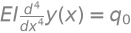

In [70]:
import sympy as sym
x, EI, q0 = sym.symbols('x EI q_0')
l = sym.symbols('l', positive=True)
y = sym.Function('y')(x)
eq = sym.Eq(EI*y.diff(x, 4), q0)
eq

Solution of the differential equation

In [71]:
res = sym.dsolve(eq).args[1]
res

Determining the integration constants - solving the system of boundary-condition equations

In [72]:
eq1 = sym.Eq(res.subs(x, 0), 0)
eq2 = sym.Eq(sym.diff(res, x).subs(x, 0), 0)
eq3 = sym.Eq(res.subs(x, l), 0)
eq4 = sym.Eq(sym.diff(res, x, 2).subs(x, l), 0)

system = (eq1, eq2, eq3, eq4)
system

In [73]:
constants = sym.solve(system, ['C1', 'C2', 'C3', 'C4'])
constants

In [74]:
final_solution = res.subs(constants)
final_solution

Let us substitute the data:

In [75]:
data = {l:L, EI:E*I, q0:q}
deflection = final_solution.subs(data)

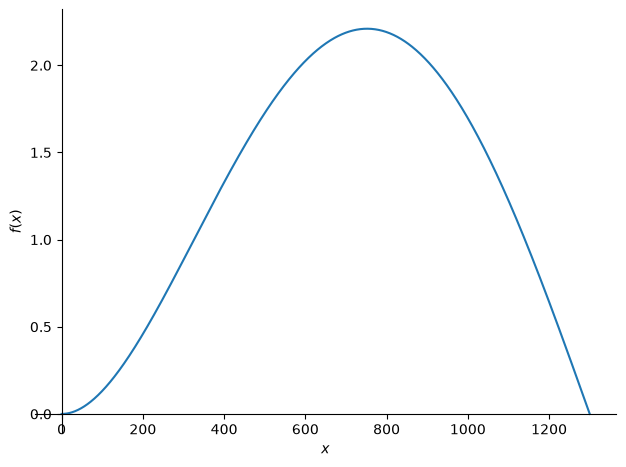

In [76]:
sym.plot(deflection, (x, 0, L))

Let us prepare a function of the final solution

In [77]:
f_deflection = sym.lambdify(x, deflection)

### Numerically - `scipy.integrate.solve_bvp`:

## Problem 3: beam with two spans

<img src="fig/vaje/konzola_s_podporo_dve_polji.png" width=550>

**Span I:**

Differential equation (Euler-Bernoulli):

$$EI \, y_I^{IV} = q(x) = 0$$

New unknowns:

$$\begin{aligned}
y_0 = y_{I}(x)\\
y_1 = y_{I}'(x)\\
y_2 = y_{I}''(x)\\
y_3 = y_{I}'''(x)
\end{aligned}$$


**Span II:**

Differential equation (Euler-Bernoulli):

$$EI \, y_{II}^{IV} = q(x) = 0$$

New unknowns:

$$\begin{aligned}
y_4 = y_{II}(x)\\
y_5 = y_{II}'(x)\\
y_6 = y_{II}''(x)\\
y_7 = y_{II}'''(x)
\end{aligned}$$

**8 new unknowns!**

**First derivatives of the new unknowns:**

$$\begin{aligned}
&y_0' = y_1\\
&y_1' = y_2\\
&y_2' = y_3\\
&y_3' = y^{IV}(x) = 0\\
\end{aligned}$$

$$\begin{aligned}
&y_4' = y_5\\
&y_5' = y_6\\
&y_6' = y_7\\
&y_7' = y^{IV}(x) = 0
\end{aligned}$$

In [79]:
L = 2000 # mm
E = 210000 # MPa
I = 2e6 # mm^4
F = -5000

**Boundary conditions (8!):**

$x \in [0, L/2]$

$x = 0 \quad \Rightarrow \quad \text{edge A}$

$x = L/2 \quad \Rightarrow \quad \text{edge B}$


$$\begin{aligned}
y_0(x_I=0) = y_0^A = 0\\
y_1(x_I=0) = y_1^A = 0\\
y_4(x_{II}=L/2) = y_4^B = 0\\
y_6(x_{II}=L/2) = y_6^B  = 0
\end{aligned}$$

Conditions at the transition between spans:

$$\begin{aligned}
y_0(x_I=L/2) &= y_4(x_{II}=0)\\
y_1(x_I=L/2) &= y_5(x_{II}=0)\\
y_2(x_I=L/2) &= y_6(x_{II}=0)\\
\end{aligned}$$

Shear force at the transition between spans:

$$T(x_I=L/2) = T(x_{II}=0) + F, \quad \quad T(x) = -EI \, y'''(x)$$

$$y_3(x_I=L/2) = y_7(x_{II}=0) - \frac{F}{EI}$$

### Numerical solution: